In [1]:
import numpy as np
import pandas as pd
import scanpy as sc


import plotnine as p9

import liana as li
import decoupler as dc
import omnipath as op

# Import DESeq2
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

In [2]:
adata = sc.read_h5ad('/cluster/pixstor/warrenwc-lab/users/evan/SingleCell/Total_lung/clusters_annotated.h5ad')
adata

AnnData object with n_obs × n_vars = 37608 × 2706
    obs: 'sample_id', 'population', 'n_genes_by_counts', 'n_genes', 'percent_ribo', 'percent_mito', 'n_counts', 'leiden', 'Total Population', 'cell type'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Total Population_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'population_colors', 'rank_genes_groups', 'sample_id_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [3]:
raw_adata = sc.read_h5ad('/cluster/pixstor/warrenwc-lab/users/rachel/single-cell/251217-chickenRBCs/3-cluster/raw_counts.h5ad')
raw_adata

AnnData object with n_obs × n_vars = 37608 × 15590
    obs: 'sample_id', 'population', 'n_genes_by_counts', 'n_genes', 'percent_ribo', 'percent_mito', 'n_counts'
    var: 'n_cells'
    uns: 'sample_id_colors'

In [4]:
# Make a copy of the full raw counts
raw = raw_adata.copy()

# need counts in a layer --- add here
raw.layers["counts"] = raw.X.copy()

# also add name to a layer --- add here
raw.var['name'] = raw.var_names

In [5]:
raw

AnnData object with n_obs × n_vars = 37608 × 15590
    obs: 'sample_id', 'population', 'n_genes_by_counts', 'n_genes', 'percent_ribo', 'percent_mito', 'n_counts'
    var: 'n_cells', 'name'
    uns: 'sample_id_colors'
    layers: 'counts'

In [6]:
## Add raw data info to clustering adata output

# Convert .raw to an AnnData object (preserves obs from the current adata)
adata = adata.raw.to_adata()

# Subset raw to match adata's cells and genes
raw_subset = raw[adata.obs_names, adata.var_names].copy()

# Add counts layer
adata.layers["counts"] = raw_subset.X.copy()

# Add gene names for convenience
adata.var['name'] = adata.var_names

In [7]:
adata

AnnData object with n_obs × n_vars = 37608 × 15590
    obs: 'sample_id', 'population', 'n_genes_by_counts', 'n_genes', 'percent_ribo', 'percent_mito', 'n_counts', 'leiden', 'Total Population', 'cell type'
    var: 'n_cells', 'percent_cells_expressing', 'name'
    uns: 'Total Population_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'population_colors', 'rank_genes_groups', 'sample_id_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [8]:
adata.obs

,sample_id,population,n_genes_by_counts,n_genes,percent_ribo,percent_mito,n_counts,leiden,Total Population,cell type
AAACCAGCAAAGTCTC-1,C1_GEX,adult,768,768,5.315402,0.000000,3123.0,0,Erythrocytes,Erythrocytes
AAACCAGCAGTAGCCC-1,C1_GEX,adult,540,540,10.983606,0.000000,1220.0,0,Erythrocytes,Erythrocytes
AAACCATTCGTACCTT-1,C1_GEX,adult,645,645,6.348282,0.000000,1717.0,0,Erythrocytes,Erythrocytes
AAACCATTCGTATACG-1,C1_GEX,adult,519,519,4.884792,0.184332,1085.0,0,Erythrocytes,Erythrocytes
AAACCCATCCACCATT-1,C1_GEX,adult,557,557,1.988376,0.000000,6538.0,0,Erythrocytes,Erythrocytes
...,...,...,...,...,...,...,...,...,...,...
GTTGTGCAGCATTTGG-1-1,E4_GEX,embryo,588,588,13.630491,0.064599,1548.0,0,Erythrocytes,Erythrocytes
GTTGTGCAGCGTTAGC-1,E4_GEX,embryo,514,514,7.725631,0.000000,1385.0,0,Erythrocytes,Erythrocytes
GTTGTGGGTACTTTCG-1,E4_GEX,embryo,943,943,3.352608,0.012995,15391.0,0,Erythrocytes,Erythrocytes
GTTGTGGGTCAAGGCC-1,E4_GEX,embryo,531,531,6.583463,0.031201,3205.0,0,Erythrocytes,Erythrocytes


In [9]:
sample_key = 'sample_id'
groupby = 'cell type'
condition_key = 'population'

In [10]:
# filter cells and genes
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

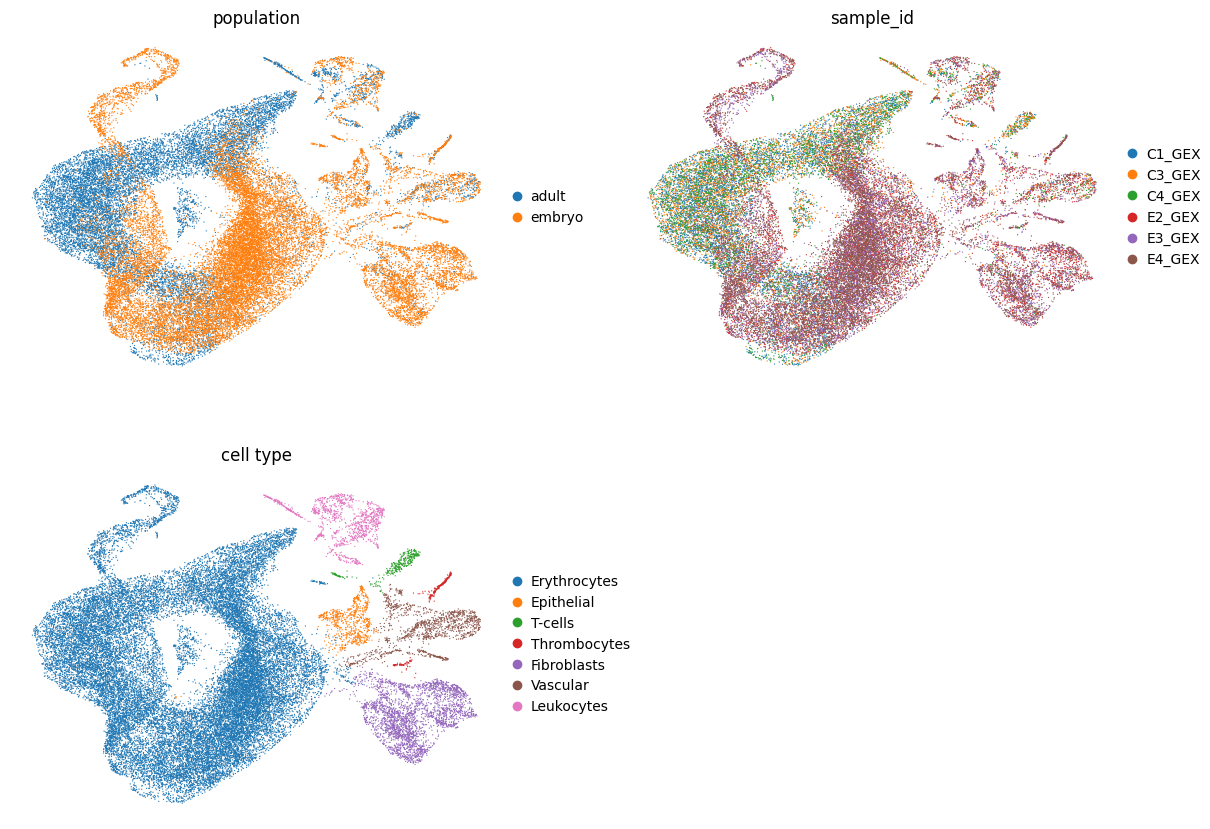

In [11]:
# Show pre-computed UMAP
sc.pl.umap(adata, color=[condition_key, sample_key, groupby], frameon=False, ncols=2)

In [12]:
pdata = dc.pp.pseudobulk(
    adata,
    sample_col=sample_key,
    groups_col=groupby,
    layer='counts',
    mode='sum'
)
pdata

AnnData object with n_obs × n_vars = 42 × 15268
    obs: 'sample_id', 'cell type', 'population', 'leiden', 'Total Population', 'psbulk_cells', 'psbulk_counts'
    var: 'n_cells', 'percent_cells_expressing', 'name'
    layers: 'psbulk_props'

In [13]:
# After pseudobulk
pdata.layers["counts"] = pdata.X.copy()  # store the summed counts in a layer
pdata.X = pdata.layers["counts"]  # DESeq2 expects counts in X

In [14]:
# filter samples based on number of cells and counts
dc.pp.filter_samples(pdata, min_cells = 10, min_counts=100)

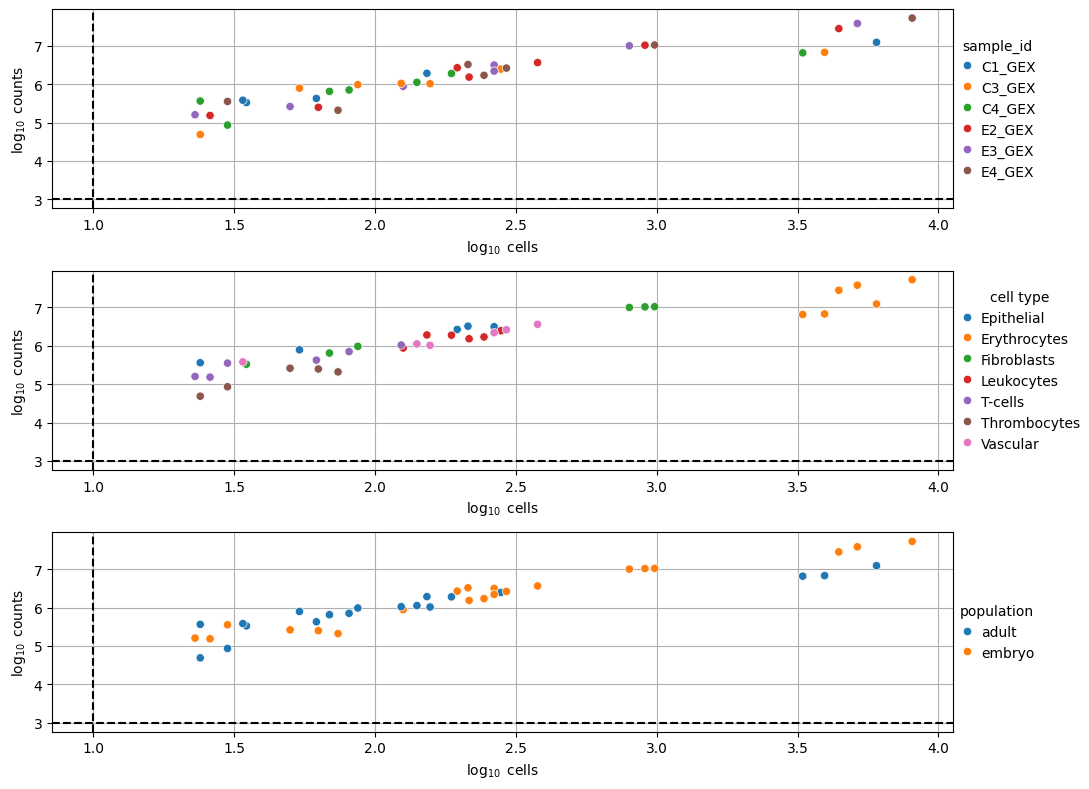

In [15]:
dc.pl.filter_samples(pdata, groupby=[sample_key, groupby, condition_key], figsize=(11, 8))

In [16]:
pdata

AnnData object with n_obs × n_vars = 40 × 15268
    obs: 'sample_id', 'cell type', 'population', 'leiden', 'Total Population', 'psbulk_cells', 'psbulk_counts'
    var: 'n_cells', 'percent_cells_expressing', 'name'
    layers: 'psbulk_props', 'counts'

In [17]:
pdata[pdata.obs["Total Population"]=="Erythrocytes"]

View of AnnData object with n_obs × n_vars = 6 × 15268
    obs: 'sample_id', 'cell type', 'population', 'leiden', 'Total Population', 'psbulk_cells', 'psbulk_counts'
    var: 'n_cells', 'percent_cells_expressing', 'name'
    layers: 'psbulk_props', 'counts'

In [18]:
dea_results = {}
quiet = True

for cell_group in pdata.obs[groupby].unique():
    print(cell_group)
    # Select cell profiles
    ctdata = pdata[pdata.obs[groupby] == cell_group].copy()
    if len(ctdata.obs) < 5 :
        continue

    # Obtain genes that pass the edgeR-like thresholds
    # NOTE: QC thresholds might differ between cell types, consider applying them by cell type
    expr_df = pd.DataFrame(
    ctdata.X,
    index=ctdata.obs_names,
    columns=ctdata.var_names
    )

    min_count_threshold = 1
    samples_with_min_count = (expr_df >= min_count_threshold).sum(axis=0)
    min_total_count = expr_df.sum(axis=0)

    genes = expr_df.columns[
        (samples_with_min_count >= 2) & (min_total_count >= 5)
    ].tolist()

    # Check that both groups exist in this cell type
    if ctdata.obs[condition_key].nunique() < 2:
        print(f"Skipping {cell_group}: only one population present")
        continue

    # Filter by these genes
    ctdata = ctdata[:, genes].copy()
    ctdata.obs['population'] = pd.Categorical(
        ctdata.obs['population'],
        categories=['embryo', 'adult'],  # <-- reference must be first
        ordered=True
    )   
    # Build DESeq2 object
    # NOTE: this data is actually paired, so one could consider fitting the patient label as a confounder
    dds = DeseqDataSet(
        adata=ctdata,
        design_factors=condition_key,
        ref_level=[condition_key, 'embryo'], # set control as reference
        refit_cooks=True,
        quiet=quiet
    )
    
    # Compute LFCs
    dds.deseq2()
    # Contrast between stim and ctrl
    stat_res = DeseqStats(dds, contrast=[condition_key, 'adult', 'embryo'], quiet=quiet)
    stat_res.quiet = quiet
    # Compute Wald test
    stat_res.summary()
    # Shrink LFCs
    stat_res.lfc_shrink(coeff=f'{condition_key}[T.adult]') # {condition_key}_cond_vs_ref
    
    dea_results[cell_group] = stat_res.results_df

Epithelial


/tmp/ipykernel_822311/445307266.py:41: DeprecationWarning: ref_level is deprecated and no longer has any effect. It will beremoved in a future release.
/tmp/ipykernel_822311/445307266.py:41: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
/cluster/pixstor/warrenwc-lab/users/evan/.conda/envs/scanpy/lib/python3.11/site-packages/pydeseq2/dds.py:548: UserWarning: As the residual degrees of freedom is less than 3, the distribution of log dispersions is especially asymmetric and likely to be poorly estimated by the MAD.


Erythrocytes


/tmp/ipykernel_822311/445307266.py:41: DeprecationWarning: ref_level is deprecated and no longer has any effect. It will beremoved in a future release.
/tmp/ipykernel_822311/445307266.py:41: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.


Fibroblasts


...

/tmp/ipykernel_822311/445307266.py:41: DeprecationWarning: ref_level is deprecated and no longer has any effect. It will beremoved in a future release.
/tmp/ipykernel_822311/445307266.py:41: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.


Thrombocytes


/tmp/ipykernel_822311/445307266.py:41: DeprecationWarning: ref_level is deprecated and no longer has any effect. It will beremoved in a future release.
/tmp/ipykernel_822311/445307266.py:41: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
/cluster/pixstor/warrenwc-lab/users/evan/.conda/envs/scanpy/lib/python3.11/site-packages/pydeseq2/dds.py:548: UserWarning: As the residual degrees of freedom is less than 3, the distribution of log dispersions is especially asymmetric and likely to be poorly estimated by the MAD.


Vascular


/tmp/ipykernel_822311/445307266.py:41: DeprecationWarning: ref_level is deprecated and no longer has any effect. It will beremoved in a future release.
/tmp/ipykernel_822311/445307266.py:41: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.


In [19]:
# concat results across cell types
dea_df = pd.concat(dea_results)
dea_df = dea_df.reset_index().rename(columns={'level_0': groupby,'level_1':'index'}).set_index('index')
dea_df

,cell type,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
index,,,,,,,
HMOX1,Epithelial,5.816047,0.038187,0.621769,0.166043,8.681235e-01,9.590994e-01
CYFIP1,Epithelial,254.279196,-0.939557,0.337112,-3.238344,1.202259e-03,1.320221e-02
PIM3,Epithelial,78.489456,1.999396,0.329823,6.382581,1.741276e-10,1.368322e-08
MPHOSPH8,Epithelial,47.637576,0.366297,0.392524,1.229896,2.187359e-01,5.319565e-01
IL17REL,Epithelial,117.863542,2.241194,0.307812,7.552615,4.266035e-14,7.054876e-12
...,...,...,...,...,...,...,...
ENSGALG00000051372,Vascular,2.180939,0.426768,0.957499,1.664901,9.593246e-02,NaN
ENSGALG00000047462,Vascular,4.392320,0.375839,0.801128,1.285372,1.986625e-01,4.144302e-01
ENSGALG00000053925,Vascular,49.693653,0.008966,0.270429,0.036979,9.705015e-01,9.874050e-01


In [20]:
# PyDeseq Seems to intrdoce NAs for some p-values
# NOTE: there sometimes some NaN being introduced, best to double check that, in this case it's only for a single gene, but it might be a problem.
len(dea_df[dea_df.isna().any(axis=1)])

15773

In [21]:
# Remove rows with any missing values (NaN in log2FC, pvals, padj, stat)
removed_rows = dea_df[dea_df.isna().any(axis=1)]
removed_rows.to_csv("Liana/removed_NA_rows.csv", index=True)

# Keep only clean rows
dea_df = dea_df.dropna()
print(f"Removed {len(removed_rows)} rows containing NaNs.")

Removed 15773 rows containing NaNs.


In [22]:
dea_df

,cell type,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
index,,,,,,,
HMOX1,Epithelial,5.816047,0.038187,0.621769,0.166043,8.681235e-01,9.590994e-01
CYFIP1,Epithelial,254.279196,-0.939557,0.337112,-3.238344,1.202259e-03,1.320221e-02
PIM3,Epithelial,78.489456,1.999396,0.329823,6.382581,1.741276e-10,1.368322e-08
MPHOSPH8,Epithelial,47.637576,0.366297,0.392524,1.229896,2.187359e-01,5.319565e-01
IL17REL,Epithelial,117.863542,2.241194,0.307812,7.552615,4.266035e-14,7.054876e-12
...,...,...,...,...,...,...,...
ENSGALG00000054106,Vascular,28.548724,0.685604,0.425592,2.073822,3.809581e-02,1.362164e-01
ENSGALG00000047462,Vascular,4.392320,0.375839,0.801128,1.285372,1.986625e-01,4.144302e-01
ENSGALG00000053925,Vascular,49.693653,0.008966,0.270429,0.036979,9.705015e-01,9.874050e-01


In [23]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [24]:
# Save DEA results to CSV
dea_df.to_csv("Liana/dea_results.csv", index=True)

DEA TO LIGAND - RECEPTOR INTERACTIONS
Now that we have DEA results per gene, we can combine them into statistics of potentially deregulated ligand-receptor interactions.

To do so, liana provides a simple function li.multi.df_to_lr that calculates average expression as well as proportions based on the passed adata object, and combines those with the DEA results and a ligand-receptor resource. Since in this case we want to focus on gene statics relevant to the condition (stim), let’s subset the adata to those and normalize the counts.

In [25]:
adata = adata[adata.obs[condition_key]=='adult'].copy()

In [26]:
### START LIANA

li.mt.show_methods()

# Select Resource (Default: Consensus)
resource = li.rs.select_resource('consensus')
resource.head()

,ligand,receptor
0,LGALS9,PTPRC
1,LGALS9,MET
2,LGALS9,CD44
3,LGALS9,LRP1
4,LGALS9,CD47


In [27]:
## download chicken homologs of human genes and perform Human-to-Chicken Ortholog Mapping

map_df = li.rs.get_hcop_orthologs(url='https://ftp.ebi.ac.uk/pub/databases/genenames/hcop/human_chicken_hcop_fifteen_column.txt.gz',
                                   columns=['human_symbol', 'chicken_symbol'],
                                   # NOTE: HCOP integrates multiple resource, so we can filter out mappings in at least 3 of them for confidence
                                   min_evidence=3
                                   )
# rename the columns to source and target, respectively for the original organism and the target organism

map_df = map_df.rename(columns={'human_symbol':'source', 'chicken_symbol':'target'})
map_df.tail()

# Translate Ligand-Receptor Database to Chicken Genes

chicken = li.rs.translate_resource(resource,
                                 map_df=map_df,
                                 columns=['ligand', 'receptor'],
                                 replace=True,
                                 # Here, we will be harsher and only keep mappings that don't map to more than 1 chicken gene
                                 one_to_many=1
                                 )

In [28]:
chicken

,ligand,receptor
14,NRG2,ERBB2_ERBB3
19,ADAM10,MET
20,ADAM10,IL6R
21,ADAM10,CD44
24,ADAM10,NOTCH1
...,...,...
4590,F8,LRP4
4605,CNTF,CRLF1
4607,NRG3,EGFR
4617,INHBA,ACTR2


In [29]:
# import all individual methods
from liana.method import singlecellsignalr, connectome, cellphonedb, natmi, logfc, cellchat, geometric_mean

In [30]:
lr_res = li.multi.df_to_lr(adata,
                           dea_df=dea_df,
                           resource=chicken, # NOTE: consensus uses HUMAN gene symbols!
                           expr_prop=0.1, # calculated for adata as passed - used to filter interactions
                           groupby=groupby,
                           stat_keys=['stat', 'pvalue', 'padj'],
                           use_raw=False,
                           complex_col='stat', # NOTE: we use the Wald Stat to deal with complexes
                           verbose=True,
                           return_all_lrs=False,
                           )

Using `.X`!
360 features of mat are empty, they will be removed.


Using provided `resource`.


/cluster/pixstor/warrenwc-lab/users/evan/.conda/envs/scanpy/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
Features in adata and dea_df are mismatched.
0.26 of entities in the resource are missing from the data.


NOTE FROM LIANA DOCUMENTATION:

Dealing with heteromeric complexes: LIANA will filter lowly-expressed interactions, i.e. those for which any of the genes are not expressed in at least 0.1 of the cells (by default) in the AnnData object. This can be adjusted with the expr_prop parameter.

Moreover, to deal with complexes for each cell type, as either source or target of the potential CCC events, LIANA will find and assign the subunit of a complex with the lowest gene expression (by default) as the subunit of interest, and will then use the stats for that subunit as the stats of the whole protein complex.

VISUALIZE THE RESULTS
PER LIANA: Moreover, by averaging the statistics across the ligand and receptor, we are focusing on the interactions for which both the ligand and receptor are deregulated in the same direction, i.e. both up or both down. However, this might ignore interactions in which e.g. the the ligand is deregulated while the receptor is not, or such where they are deregulated in opposite directions. These could represent potential inhibitory mechanisms, but we leave this to the user to explore.

In [31]:
lr_res = lr_res.sort_values("interaction_stat", ascending=False, key=abs)
lr_res

,ligand,receptor,ligand_complex,receptor_complex,source,ligand_stat,ligand_pvalue,ligand_padj,ligand_expr,ligand_props,...,receptor_pvalue,receptor_padj,receptor_expr,receptor_props,interaction_stat,interaction_pvalue,interaction_padj,interaction_expr,interaction_props,interaction
57,IL15,IL2RA,IL15,IL2RA,Erythrocytes,36.516491,6.070834e-292,2.079463e-288,1.241476,0.437764,...,3.714236e-01,5.857204e-01,0.269291,0.163695,18.705150,1.857118e-01,2.928602e-01,0.755384,0.300730,IL15^IL2RA
68,B2M,CD1C,B2M,CD1C,Erythrocytes,30.132347,1.827185e-199,3.755231e-196,4.106340,0.999699,...,1.118645e-09,3.086227e-08,0.467412,0.285251,18.111919,5.593226e-10,1.543114e-08,2.286876,0.642475,B2M^CD1C
18,IL15,IL2RA,IL15,IL2RA,Erythrocytes,36.516491,6.070834e-292,2.079463e-288,1.241476,0.437764,...,3.190898e-01,6.041419e-01,0.419435,0.178030,17.760080,1.595449e-01,3.020709e-01,0.830455,0.307897,IL15^IL2RA
1683,NCAM1,PTPRA,NCAM1,PTPRA,Fibroblasts,-24.895825,8.256647e-137,4.748811e-133,0.301732,0.180851,...,5.719205e-06,7.162345e-05,0.370314,0.291734,-14.716169,2.859603e-06,3.581172e-05,0.336023,0.236293,NCAM1^PTPRA
1332,NCAM1,ROBO1,NCAM1,ROBO1,Fibroblasts,-24.895825,8.256647e-137,4.748811e-133,0.301732,0.180851,...,3.340731e-03,1.666356e-02,0.824357,0.420213,-13.915168,1.670366e-03,8.331781e-03,0.563044,0.300532,NCAM1^ROBO1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
684,TNFSF11,LGR4,TNFSF11,LGR4,T-cells,-0.529018,5.967932e-01,8.229764e-01,0.322076,0.234848,...,6.048650e-01,7.574311e-01,0.349732,0.287234,-0.005800,6.008291e-01,7.902038e-01,0.335904,0.261041,TNFSF11^LGR4
1264,BMP2,ACTR2,BMP2,ACTR2,Fibroblasts,1.128912,2.589350e-01,4.396636e-01,0.477386,0.382979,...,2.541588e-01,5.342311e-01,1.305866,0.787879,-0.005697,2.565469e-01,4.869473e-01,0.891626,0.585429,BMP2^ACTR2
1636,COPA,CD74,COPA,CD74,Fibroblasts,-2.167008,3.023422e-02,9.471248e-02,0.465850,0.377660,...,2.937782e-02,1.026638e-01,3.194524,0.902755,0.005685,2.980602e-02,9.868815e-02,1.830187,0.640207,COPA^CD74
699,FAM3C,LAMP1,FAM3C,LAMP1,T-cells,0.103140,9.178517e-01,9.694876e-01,0.411319,0.310606,...,9.229571e-01,9.582792e-01,1.296876,0.718085,0.003215,9.204044e-01,9.638834e-01,0.854098,0.514346,FAM3C^LAMP1


<Axes: >

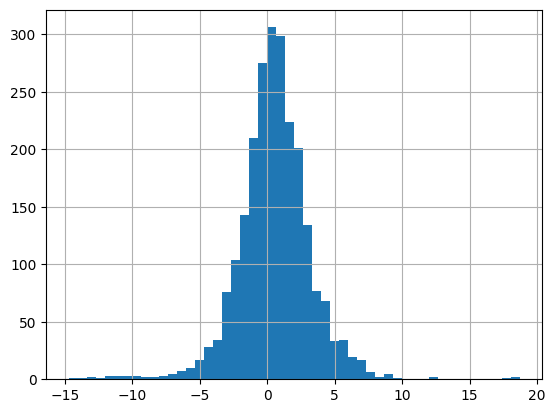

In [32]:
# Let's visualize how this looks like for all interactions  (across all cell types)
lr_res = lr_res.sort_values("interaction_stat", ascending=False)
lr_res['interaction_stat'].hist(bins=50)

Top interactions according to their Wald statistic to plot the statistics for the ligands & receptors involved in those interactions across cell types

In [33]:
lr_res.columns.tolist()

['ligand',
 'receptor',
 'ligand_complex',
 'receptor_complex',
 'source',
 'ligand_stat',
 'ligand_pvalue',
 'ligand_padj',
 'ligand_expr',
 'ligand_props',
 'target',
 'receptor_stat',
 'receptor_pvalue',
 'receptor_padj',
 'receptor_expr',
 'receptor_props',
 'interaction_stat',
 'interaction_pvalue',
 'interaction_padj',
 'interaction_expr',
 'interaction_props',
 'interaction']

In [48]:
lr_res_sig = lr_res[lr_res['interaction_padj'].notna() & (lr_res['interaction_padj'] < 0.05)]

/cluster/pixstor/warrenwc-lab/users/evan/.conda/envs/scanpy/lib/python3.11/site-packages/liana/plotting/_common.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/home/emvrn/.local/lib/python3.11/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_text : Removed 15 rows containing missing values.


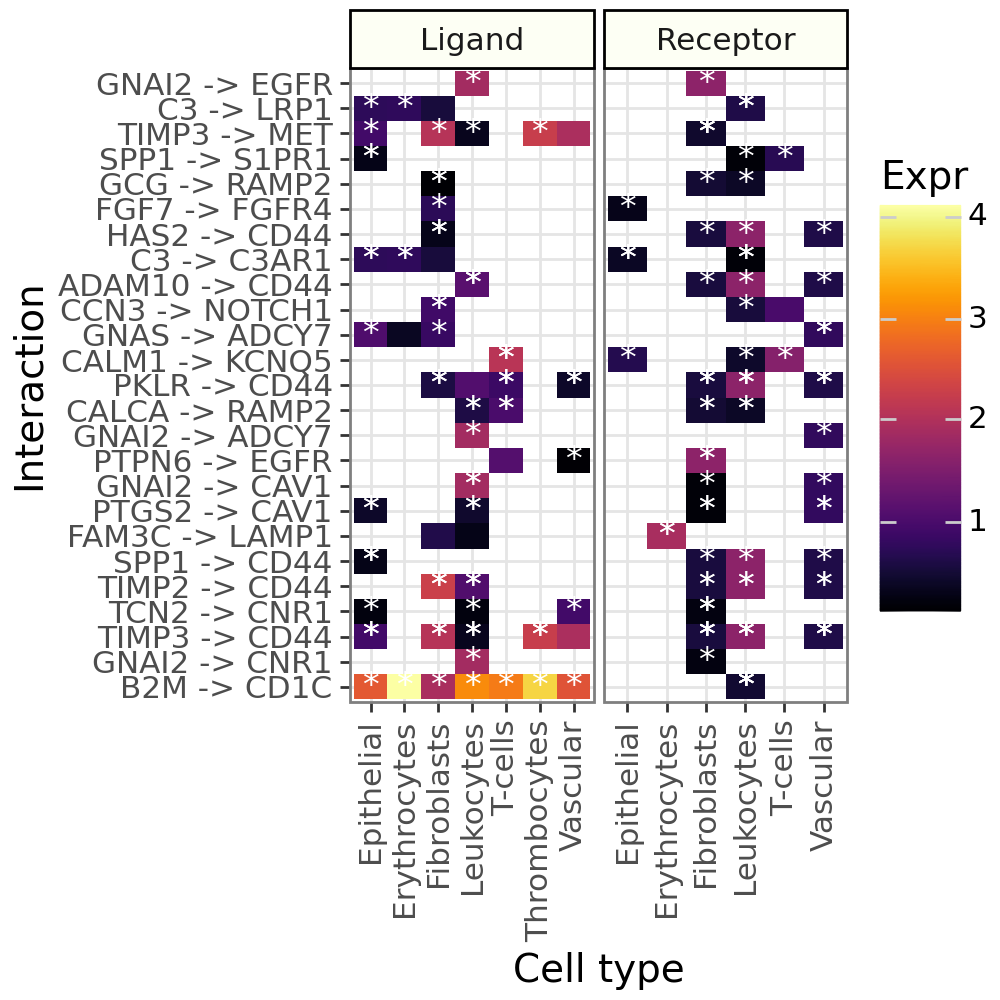

In [50]:
plot = li.pl.tileplot(liana_res=lr_res_sig,
               fill = 'expr',
               label='padj',
               label_fun = lambda x: '*' if x < 0.05 else np.nan,
               top_n=25,
               orderby = 'interaction_stat',
               orderby_ascending = False,
               orderby_absolute = False,
               cmap = 'inferno',
               source_title='Ligand',
               target_title='Receptor',
               )
plot

In [36]:
plot.save("Liana/tile_top25.png", dpi=300, width=8, height=10)

/home/emvrn/.local/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 8 x 10 in image.
/home/emvrn/.local/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: Liana/tile_top25.png
/home/emvrn/.local/lib/python3.11/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_text : Removed 439 rows containing missing values.


LIGAND-RECEPTOR PLOT
Visualize the mean Wald statistic between the ligand & receptor, together with the pvalues for the ligand.

In [51]:
# base plot
plot = li.pl.dotplot(
    liana_res=lr_res_sig,
    colour='interaction_stat',
    size='interaction_padj',
    inverse_size=True,
    orderby='interaction_stat',
    orderby_ascending=False,
    orderby_absolute=True,
    top_n=25,
    size_range=(0.5, 4)
)

# customize
final_plot = (
    plot
    + p9.theme_bw(base_size=14)
    + p9.scale_color_cmap('RdBu_r', limits=(-10, 10))
    + p9.theme(axis_text_x=p9.element_text(angle=90),
               figure_size=(13, 6))
)

# SAVE the plot
final_plot.save("Liana/liana_dotplot_top25.png", dpi=300, width=13, height=6)

/cluster/pixstor/warrenwc-lab/users/evan/.conda/envs/scanpy/lib/python3.11/site-packages/liana/plotting/_common.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/home/emvrn/.local/lib/python3.11/site-packages/plotnine/scales/scales.py:48: PlotnineWarning: Scale for 'color' is already present.
Adding another scale for 'color',
which will replace the existing scale.

/home/emvrn/.local/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 13 x 6 in image.
/home/emvrn/.local/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: Liana/liana_dotplot_top25.png


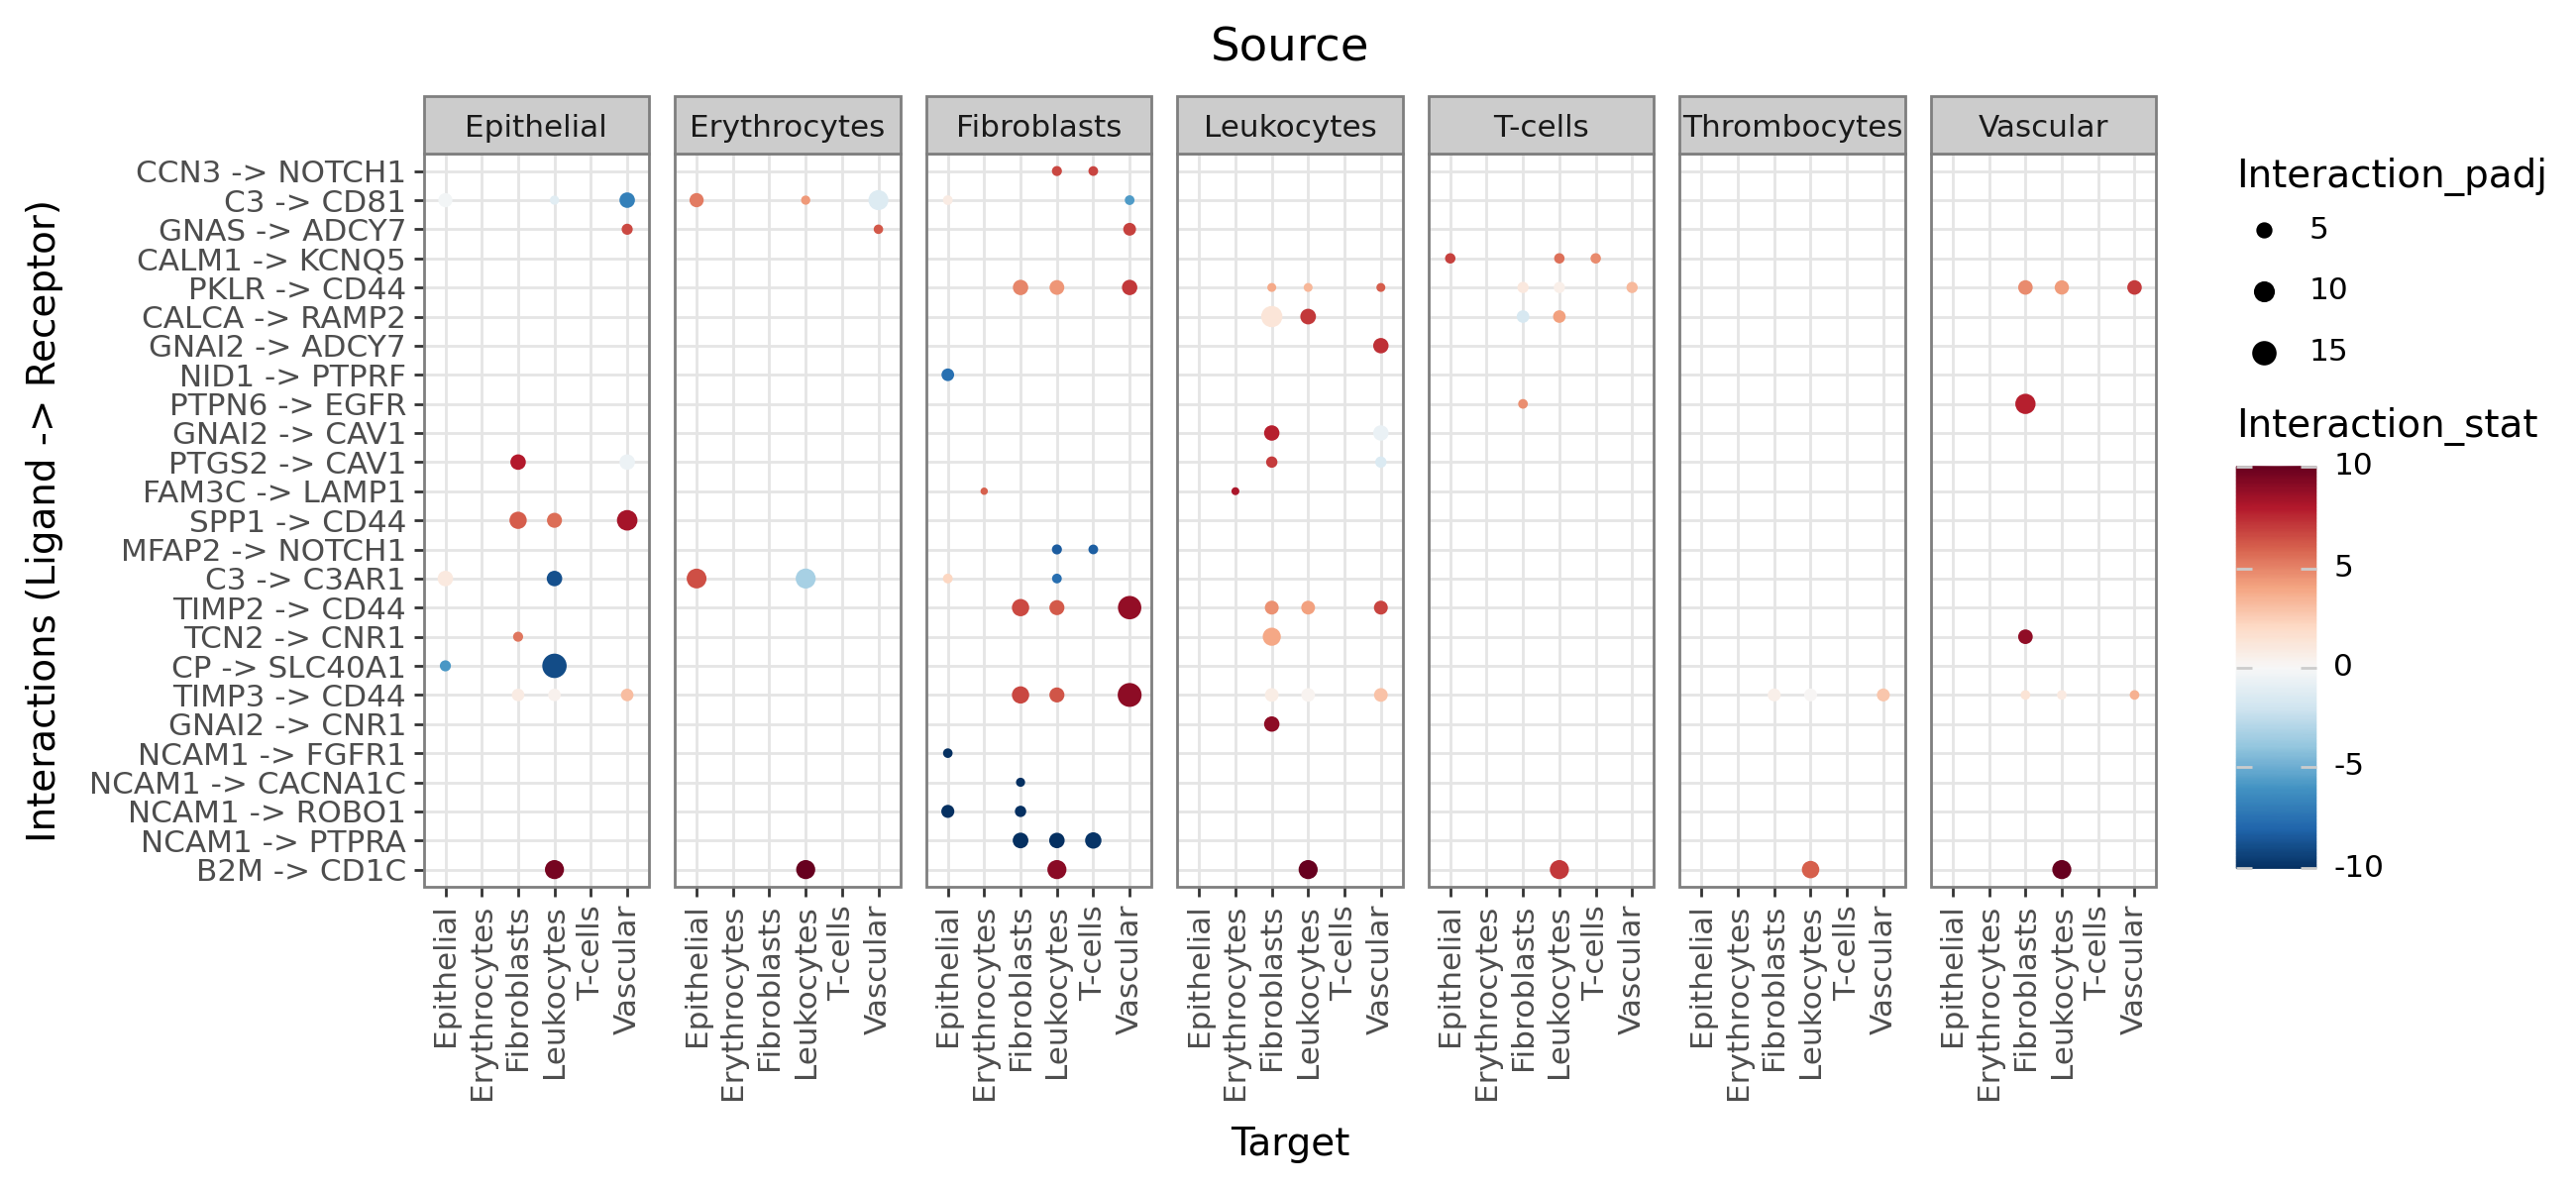

In [52]:
final_plot

In [39]:
sig_pval_rows = lr_res[lr_res["interaction_pvalue"] <= 0.05]
sig_pval_rows

,ligand,receptor,ligand_complex,receptor_complex,source,ligand_stat,ligand_pvalue,ligand_padj,ligand_expr,ligand_props,...,receptor_pvalue,receptor_padj,receptor_expr,receptor_props,interaction_stat,interaction_pvalue,interaction_padj,interaction_expr,interaction_props,interaction
68,B2M,CD1C,B2M,CD1C,Erythrocytes,30.132347,1.827185e-199,3.755231e-196,4.106340,0.999699,...,1.118645e-09,3.086227e-08,0.467412,0.285251,18.111919,5.593226e-10,1.543114e-08,2.286876,0.642475,B2M^CD1C
2085,B2M,CD1C,B2M,CD1C,Vascular,18.259665,1.733508e-74,1.012195e-70,2.546772,0.905775,...,1.118645e-09,3.086227e-08,0.467412,0.285251,12.175578,5.593226e-10,1.543114e-08,1.507092,0.595513,B2M^CD1C
2391,B2M,CD1C,B2M,CD1C,Leukocytes,18.007878,1.689833e-72,9.300838e-69,3.094350,0.982172,...,1.118645e-09,3.086227e-08,0.467412,0.285251,12.049684,5.593226e-10,1.543114e-08,1.780881,0.633712,B2M^CD1C
567,B2M,CD1C,B2M,CD1C,Epithelial,13.166550,1.367025e-39,3.029328e-36,2.598623,0.941176,...,1.118645e-09,3.086227e-08,0.467412,0.285251,9.629020,5.593226e-10,1.543114e-08,1.533017,0.613214,B2M^CD1C
1685,B2M,CD1C,B2M,CD1C,Fibroblasts,11.968745,5.180607e-33,9.131478e-31,1.940260,0.835106,...,1.118645e-09,3.086227e-08,0.467412,0.285251,9.030118,5.593226e-10,1.543114e-08,1.203836,0.560179,B2M^CD1C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1469,NCAM1,CACNA1C,NCAM1,CACNA1C,Fibroblasts,-24.895825,8.256647e-137,4.748811e-133,0.301732,0.180851,...,1.942166e-02,6.778137e-02,0.693476,0.414894,-11.279244,9.710831e-03,3.389068e-02,0.497604,0.297872,NCAM1^CACNA1C
1033,NCAM1,PTPRZ1,NCAM1,PTPRZ1,Fibroblasts,-24.895825,8.256647e-137,4.748811e-133,0.301732,0.180851,...,7.202284e-02,2.825825e-01,0.279534,0.176471,-11.548425,3.601142e-02,1.412913e-01,0.290633,0.178661,NCAM1^PTPRZ1
1185,NCAM1,PTPRA,NCAM1,PTPRA,Fibroblasts,-24.895825,8.256647e-137,4.748811e-133,0.301732,0.180851,...,8.001406e-02,3.018576e-01,0.402779,0.388235,-11.572610,4.000703e-02,1.509288e-01,0.352256,0.284543,NCAM1^PTPRA
1332,NCAM1,ROBO1,NCAM1,ROBO1,Fibroblasts,-24.895825,8.256647e-137,4.748811e-133,0.301732,0.180851,...,3.340731e-03,1.666356e-02,0.824357,0.420213,-13.915168,1.670366e-03,8.331781e-03,0.563044,0.300532,NCAM1^ROBO1


In [40]:
sig_pval_rows.to_csv("Liana/sig_interactions.csv", index=False)

In [41]:
# base plot
plot = li.pl.dotplot(
    liana_res=sig_pval_rows,
    colour='interaction_stat',
    size='interaction_padj',
    inverse_size=True,
    orderby='interaction_stat',
    orderby_ascending=False,
    orderby_absolute=True,
    #top_n=25,
    size_range=(0.5, 4)
)

# customize
all_sig = (
    plot
    + p9.theme_bw(base_size=14)
    + p9.scale_color_cmap('RdBu_r', limits=(-10, 10))
    + p9.theme(axis_text_x=p9.element_text(angle=90),
               figure_size=(11, 25))
)

# SAVE the plot
final_plot.save("figures/sig-liana_dotplot5.png", dpi=300, width=11, height=20)

/home/emvrn/.local/lib/python3.11/site-packages/plotnine/scales/scales.py:48: PlotnineWarning: Scale for 'color' is already present.
Adding another scale for 'color',
which will replace the existing scale.

/home/emvrn/.local/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 11 x 20 in image.
/home/emvrn/.local/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/sig-liana_dotplot5.png


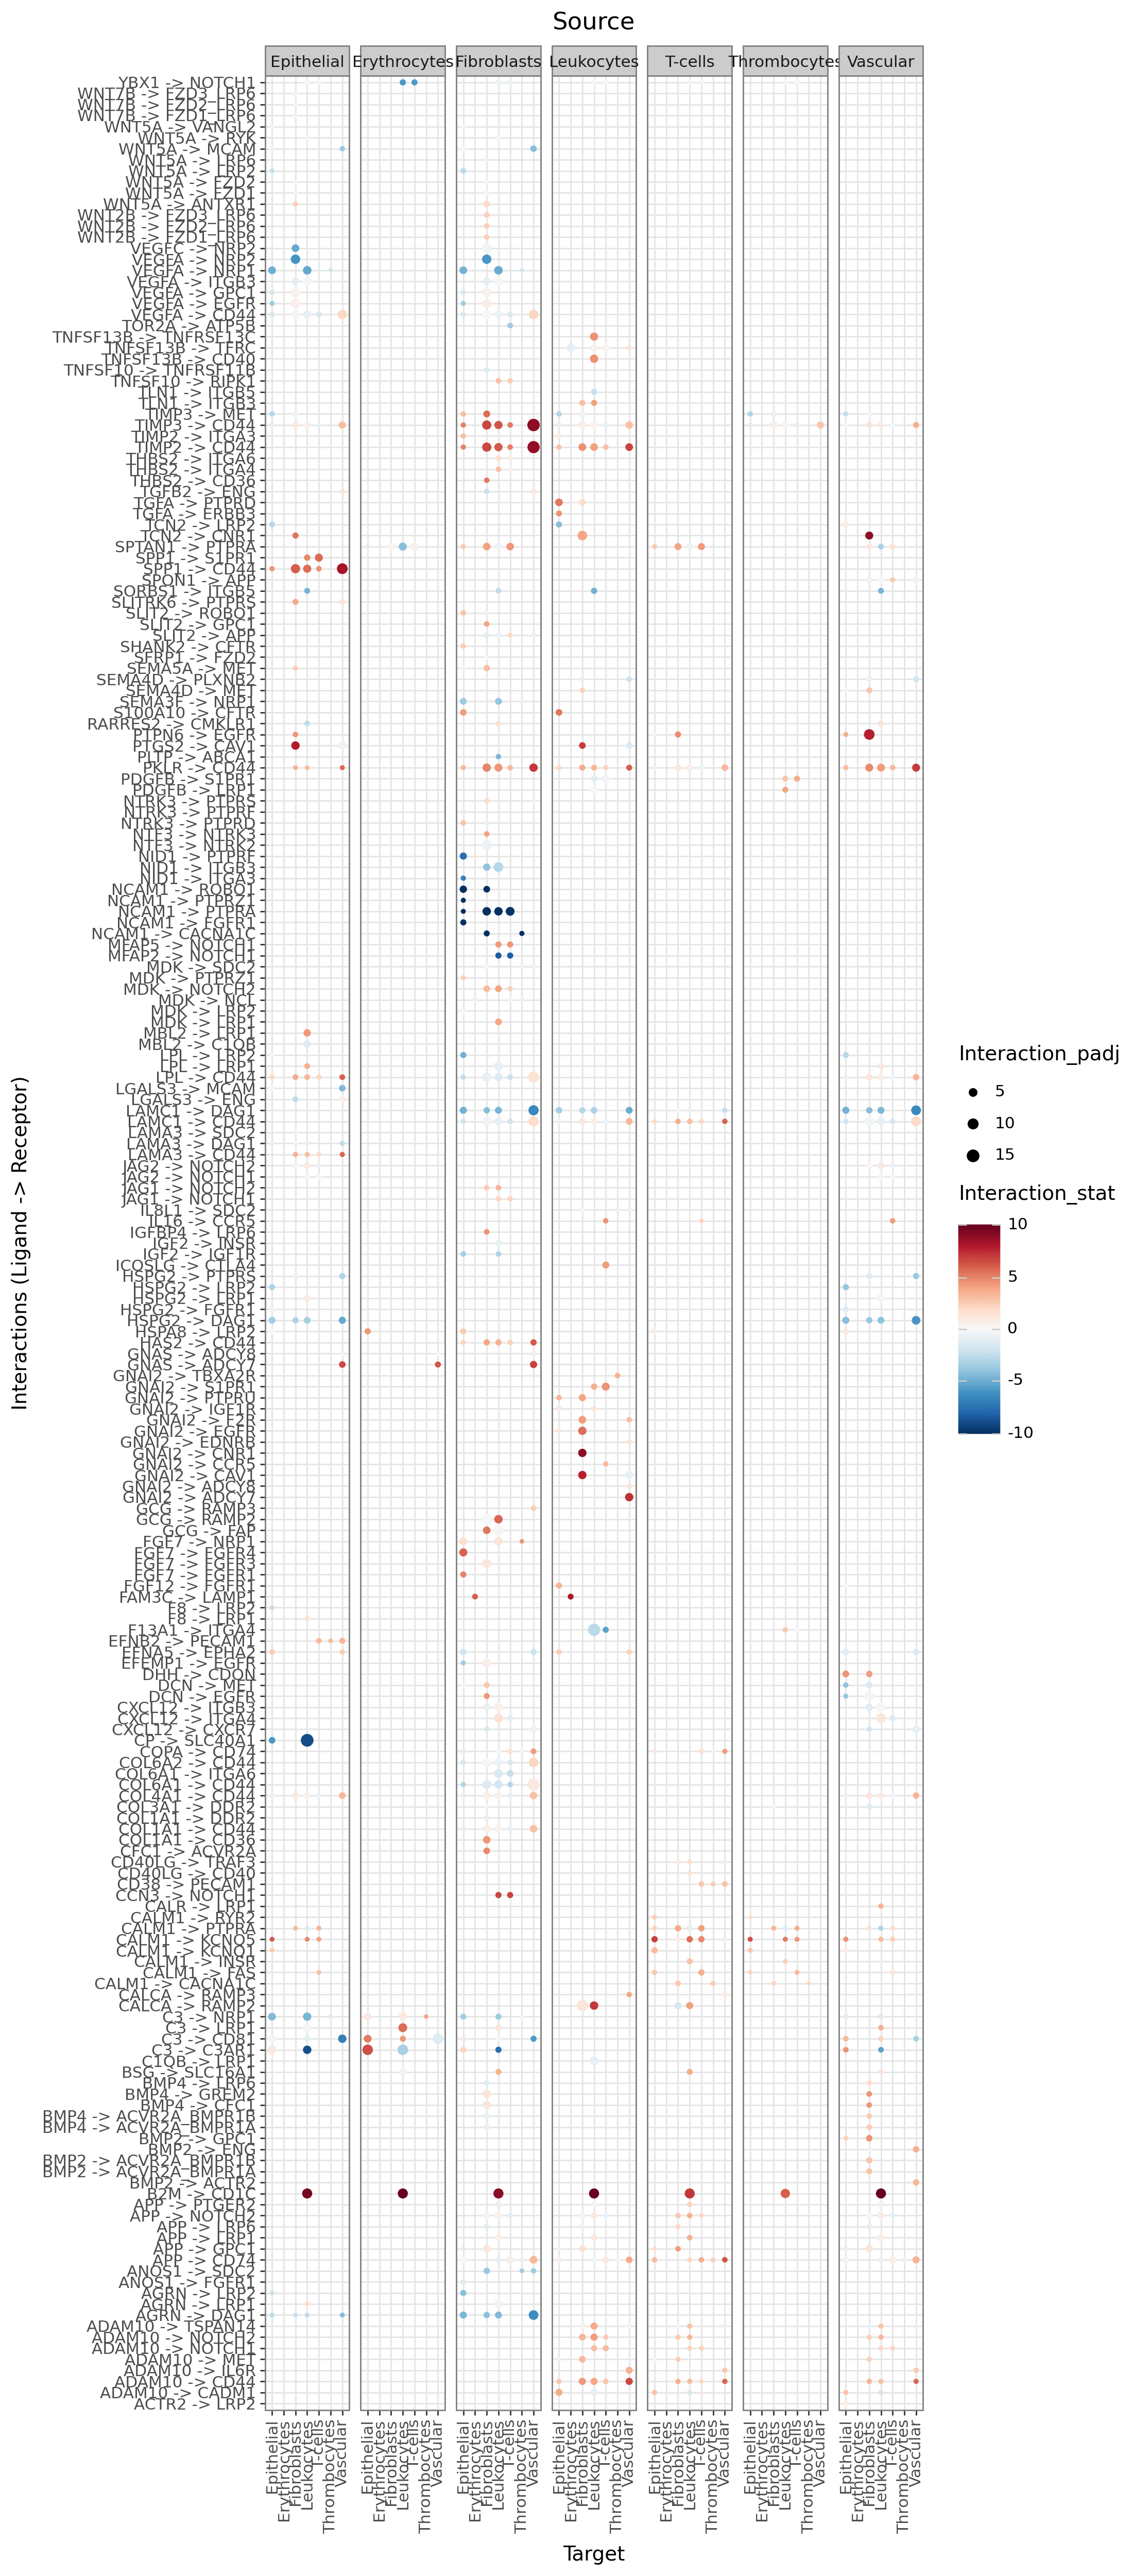

In [42]:
all_sig

In [43]:
# Count ligand frequency
ligand_counts = sig_pval_rows["ligand"].value_counts()

# Count receptor frequency
receptor_counts = sig_pval_rows["receptor"].value_counts()

# Count source cell type frequency
source_counts = sig_pval_rows["source"].value_counts()

# Count target cell type frequency
target_counts = sig_pval_rows["target"].value_counts()

ligand_counts, receptor_counts, source_counts, target_counts

(ligand
 APP       52
 ADAM10    48
 CALM1     46
 LAMC1     36
 C3        35
           ..
 ACTR2      1
 C1QB       1
 SFRP1      1
 TOR2A      1
 PLTP       1
 Name: count, Length: 95, dtype: int64,
 receptor
 CD44         159
 DAG1          36
 PTPRA         32
 NOTCH1        30
 NOTCH2        30
             ... 
 NTRK2          1
 TNFRSF11B      1
 C1QB           1
 ATP5B          1
 ABCA1          1
 Name: count, Length: 93, dtype: int64,
 source
 Fibroblasts     247
 Vascular        142
 Epithelial      134
 Leukocytes      118
 T-cells          85
 Thrombocytes     29
 Erythrocytes     20
 Name: count, dtype: int64,
 target
 Leukocytes      193
 Fibroblasts     188
 Epithelial      162
 Vascular        104
 T-cells         101
 Thrombocytes     23
 Erythrocytes      4
 Name: count, dtype: int64)